### Econ 196 Seminar: Quantitative Long-Run Global Economic History

# WEEK 11: ASSIGNMENT: Simulating Krugman on Lewis on the Development of Underdevelopment

### Due 2026-05-03 Su

<p style="text-align: right;">
    <img src="images/delong-picture.png"
     alt="J. Bradford DeLong"
     width="300"
     height="300"
     align="right"
     style="float:right; margin: 0 0 10px 10px;" />
</p>

#### J. Bradford DeLong :: delong@econ.berkeley.edu brad.delong@gmail.com delong@hey.com :: +1-925-708-0467

----

##### <<https://bcourses.berkeley.edu/courses/1551896>>
##### <<https://braddelong.substack.com/t/quantitative-long-run-global-economic>>
##### <<https://braddelong.substack.com/p/quantitative-long-run-global-economic>>

----

This file: <<https://github.com/braddelong/working_20251227/blob/main/2026-05-03-ASSIGNMENT-econ-196-week-11-development-of-underdevelopment-krugman-lewis.ipynb>>

<<https://bcourses.berkeley.edu/courses/1551896/discussion_topics/7278054?is_announcement=true>>

<<https://bcourses.berkeley.edu/courses/1551896/assignments/9071605>>

---

Download DeLong 2025-12-27 current working github repository: <<https://datahub.berkeley.edu/hub/user-redirect/git-pull?repo=https://github.com/braddelong/working_20251227&urlpath=lab/tree/working_20251227/>>

<br style="clear: both;">

---
---

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

%matplotlib inline

In [2]:
human_history_df = pd.read_feather('data/human_history_df.feather')

### Filling Holes Lewis's Argument

* **Krugman, Paul**. 1991. _Geography & Trade_. Cambridge: MIT Press. <<https://bcourses.berkeley.edu/courses/1551896/files?preview=94372051>>.
    * Paul Krugman has an _economic environment_

---
---

### Krugman's Take on the Situation

**He focuses on one example:**

* U.S. Midwestern manufacturing:
    * "The Northeast and East North Central... manufacturing
belt... U.S. 'resource extraction' employmennt [in 1910] (agriculture, mining, forestry, fisheries)... 27 percent; yet... 70 percent of manufacturing employment..."
    * "Why... did so much... manufacturing stay within this
relatively small stretch of territory?... Each individual manufacturing facility stayed... because of the advantages of being near other manufacturers..."
* "Sketch out a simple model in which geographical concentration results from demand externalities... the interaction of increasing returns, transportation costs, and demand..."
* Two locations: East & West (or core-periphery)
* Two goods: agriculture and manufactures
* Transportation costs (if manufacturing production is concentrated) vs. setup costs (if manufacturing production is split)

---
---

### Krugman's Example

<img src="images/2026-04-14-krugman-example.png" />

* Demand of 10 for a typical firm's products...
* 60% comes from farmers—split 3-3 between East and West...
* 40% comes from industrial workers—either concentrated or split 50-50
* 4-unit setup cost to produce; zero marginal cost to produce...
* 1-unit transportation cost to move goods to market...

Yes, the numbers here are rigged. Which is why we have to do more work to see how easy it is to rig the situation to get this multiple-equilibrium story...

* "There need not be multiple equilibria. The concentration of production, if it happens, depends on a demand externality. Manufacturers want to locate where the market is largest; the market is largest where the manufacturers locate. This circularity, however, need not always be strong enough to prevail over the pull of the dispersed agricultural sector..."

---
---

### Moving a Little Toward Generality...

* $ f_c, f_p, f_b $ :: share of manufacturing firms concentrated in the core, concentrated in the periphery, and spread out over both regions, respectively
    * $ f_c + f_p + f_b = 1 $
* $ \mu $ :: share of production in manufacturing
* $ \alpha_p $ :: fixed share of total production that is agriculture in the periphery
* $ d_p = \alpha_p + \mu (f_p + f_b/2) $ :: total demand in the periphery
* $ 1 - d_p $ :: total demand in the core
* $ F $ :: fixed cost of establishing a manufacturing plant
* $ \tau $ :: cost of shipping a unit of manufactures across regions
* $ \pi $ :: firm profits

&nbsp;

### Firm profits...

* for a firm with a plant only in the core: $ \pi_{core} = 1 - d_p\tau - F $
* for a firm with a plant only in the periphery: $ \pi_{per} = 1 - (1- d_p)\tau - F $
* for a firm with plants in both the periphery and the core: $ \pi_{both} = 1 - 2F $

* a peripheral plant is _loss-making_ if $ (1 - 2F) < 1 - d_p\tau - F $ 
* a core plant is _loss-making_ if $ (1 - 2F) < 1 - (1 - d_p\tau) - F $ 

&nbsp;

In [3]:
# let's calculate a firm's profits as a function of periphery demand dp
# the fixed cost of a plant F, and the transportation cost tau

# econ196_krugman_core_periphery.py

def firm_profits(dp, F, tau):
    """
    Compute profits for a manufacturing firm in Krugman-style core-periphery setup.
    
    Parameters
    ----------
    dp : float
        Total demand share in the periphery (d_p in the notes).
    F : float
        Fixed cost of establishing a manufacturing plant.
    tau : float
        Per-unit cost of shipping manufactures across regions.
    
    Returns
    -------
    dict
        {
            "core": profit with a single plant in the core (π_core),
            "periphery": profit with a single plant in the periphery (π_per),
            "both": profit with plants in both regions (π_both)
        }
    """
    pi_core = 1 - dp * tau - F
    pi_per = 1 - (1 - dp) * tau - F
    pi_both = 1 - 2 * F

    return {
        "core": pi_core,
        "periphery": pi_per,
        "both": pi_both
    }

In [4]:
# let's test this function

# when no manufacturing in the periphery...

dp = 0.3
F = 0.4
tau = 1

results = firm_profits(dp, F, tau)


print("WHEN THERE IS NO MANUFACTURING PRODUCTION IN THE PERIPHERY...")
print(" ")
print("if locate in the core, profits are: ", results["core"])
print("if locate in the periphery, profits are: ", results["periphery"])
print("if locate in both, profits are: ", results["both"])


WHEN THERE IS NO MANUFACTURING PRODUCTION IN THE PERIPHERY...
 
if locate in the core, profits are:  0.29999999999999993
if locate in the periphery, profits are:  -0.09999999999999998
if locate in both, profits are:  0.19999999999999996


In [5]:
# let's test this function again

# when manufacturing split between core and periphery..

dp = 0.5
F = 0.4
tau = 1

results = firm_profits(dp, F, tau)


print("WHEN MANUFACTURING IS SPLIT BETWEEN THE CORE AND THE PERIPHERY...")
print(" ")
print("if locate in the core, profits are: ", results["core"])
print("if locate in the periphery, profits are: ", results["periphery"])
print("if locate in both, profits are: ", results["both"])


WHEN MANUFACTURING IS SPLIT BETWEEN THE CORE AND THE PERIPHERY...
 
if locate in the core, profits are:  0.09999999999999998
if locate in the periphery, profits are:  0.09999999999999998
if locate in both, profits are:  0.19999999999999996


---
---

### A Behavioral Rule

Now that we are confident that we can calculate profits for firms that follow different strategies, suppose that firms behave like this:

**Each period...**

* a fraction $ \lambda $ of firms with one plant open a second plant
* a fraction $ \sigma $ of firms with two plants close a loss-making plant, if they have one
    
In order to analyze this situation, we have to first check which plants are money-losers. So we construct another function:

In [6]:
# profit_checks.py

def profit_making_plants(dp, F, tau):
    """
    Given d_p, F, tau, return booleans for whether a core or periphery plant
    is loss-making relative to the two-plant configuration.

    Parameters
    ----------
    dp : float
        Total demand share in the periphery (d_p).
    F : float
        Fixed cost of establishing a manufacturing plant.
    tau : float
        Cost of shipping a unit of manufactures across regions.

    Returns
    -------
    dict
        {
            "core_profit": True if a core plant is profitable,
            "periphery_profit": True if a peripheral plant is profitable
        }
    """
    profits = firm_profits(dp, F, tau)   # we first call our "firm_profits" function...
    pi_core = profits["core"]
    pi_per = profits["periphery"]
    pi_both = profits["both"]

    per_profit = pi_both > pi_core      
    core_profit = pi_both > pi_per      

    return {
        "core_profit": core_profit,
        "per_profit": per_profit,
    }

In [7]:
# let's test this function

# when no manufacturing in the periphery...

dp = 0.3
F = 0.4
tau = 1

results = profit_making_plants(dp, F, tau)


print("WHEN THERE IS NO MANUFACTURING PRODUCTION IN THE PERIPHERY...")
print(" ")
print("core plant is profitable: ", results["core_profit"])
print("peripheral plant is profitable: ", results["per_profit"])

WHEN THERE IS NO MANUFACTURING PRODUCTION IN THE PERIPHERY...
 
core plant is profitable:  True
peripheral plant is profitable:  False


In [8]:
# let's test this function again

# when manufacturing production is split...

dp = 0.5
F = 0.4
tau = 1

results = profit_making_plants(dp, F, tau)


print("WHEN MANUFACTURING PRODUCTION IS SPLIT...")
print(" ")
print("core plant is profitable: ", results["core_profit"])
print("peripheral plant is profitable: ", results["per_profit"])

WHEN MANUFACTURING PRODUCTION IS SPLIT...
 
core plant is profitable:  True
peripheral plant is profitable:  True


---
---

## We Now Have a Model We Can Simulate 

### How the Distribution of Firms Evolves from Period to Period

* Start from fractions of manufacturing in the core, periphery, and both fc, fp, fb
* fc + fp + fb = 1
* $ \alpha_p $ alpha_p is share of total production that is agricultural production in the periphery
* $ \mu $ mu is share of total production that is manufacturing production
* $ d_p = \alpha_p + \mu + (f_p + f_b/2) $ dp = alpha_p + mu * (fp + fb/2) <- demand in the periphery
* F <-- plant fixed cost
* $ \tau $ tau <-- transportation cost
* $ \lambda $ lamb <-- share of one-firm plants that open a second
* $ \sigma $ sigma <-- share of loss-making plants that are closed


In [9]:
# we now implement this by first creating a function to update 
# the firm distributionm from one period to the next

# firm_distribution_update.py

def firm_distribution_update(fb, fp, core_profit, per_profit, lamb, sigma):
    """
    Update the distribution of firms across locations (core, periphery, both)
    given profitability conditions and behavioral rules.

    Parameters
    ----------
    fb : float
        Fraction of firms with plants in both regions.
    fp : float
        Fraction of firms with a single plant in the periphery.
    core_profit : bool
        True if a core plant is profitable relative to the two-plant configuration.
    per_profit : bool
        True if a peripheral plant is profitable relative to the two-plant configuration.
    lamb : float
        Share of one-plant firms that open a second plant in a period (λ).
    sigma : float
        Share of loss-making plants that close in a period (σ).

    Returns
    -------
    dict
        {
            "fb": updated fraction of firms with plants in both regions,
            "fp": updated fraction of firms with a single peripheral plant
        }
    """

    # Loss-making closures among two-plant firms
    transition_bp = (not core_profit) * sigma * fb  # both -> periphery-only
    transition_bc = (not per_profit) * sigma * fb   # both -> core-only

    # Two-plant firms:
    #   - gain: λ * (fp + fc) from one-plant firms opening a second plant
    #   - lose: closures to core-only (transition_bc) and periphery-only (transition_bp)
    fb_new = fb + lamb * (1 - fb) - transition_bc - transition_bp

    # Periphery-only firms:
    #   - lose: λ * fp to two-plant status
    #   - gain: transition_bp from two-plant firms closing the core plant
    fp_new = (1 - lamb) * fp + transition_bp

    return {
        "fb": fb_new,
        "fp": fp_new,
    }

In [10]:
# test this function...

# define a test helper function: single_period_update_test.py

def one_period_update(fb, fp, dp, F, tau, lamb, sigma):
    """
    Compute one period's update of firm distribution for given dp, F, tau.
    """
    # First compute which plants are profitable
    profit_flags = profit_making_plants(dp, F, tau)
    core_profit = profit_flags["core_profit"]
    per_profit = profit_flags["per_profit"]

    # Then update the distribution
    new_dist = firm_distribution_update(
        fb=fb,
        fp=fp,
        core_profit=core_profit,
        per_profit=per_profit,
        lamb=lamb,
        sigma=sigma,
    )
    return {
        "dp": dp,
        "core_profit": core_profit,
        "per_profit": per_profit,
        "fb": new_dist["fb"],
        "fp": new_dist["fp"],
        "mshare": new_dist["fp"] + new_dist["fb"]/2
    }


In [11]:
# tests for firm_distribution_update with F=0.4, tau=1, dp in [0.3, 0.5, 0.7]

F = 0.4
tau = 1.0

# choose some initial distribution that sums to 1
fb0 = 0.4   # both
fp0 = 0.4   # periphery-only

# behavioral parameters
lamb = 0.05   # fraction of one-plant firms opening a second plant
sigma = 0.5  # fraction of loss-making two-plant firms that close

for dp in [0.3, 0.5, 0.7]:
    result = one_period_update(fb0, fp0, dp, F, tau, lamb, sigma)

    print(f"=== dp = {result['dp']} ===")
    print("core plant profitable?      ", result["core_profit"])
    print("periphery plant profitable? ", result["per_profit"])
    print("updated fb (both):          ", result["fb"])
    print("updated fc (core only):     ", 1-result["fb"]-result["fp"])
    print("updated fp (periphery only):", result["fp"])
    print("updated mshare):", result["mshare"])
    print()


=== dp = 0.3 ===
core plant profitable?       True
periphery plant profitable?  False
updated fb (both):           0.23000000000000004
updated fc (core only):      0.39
updated fp (periphery only): 0.38
updated mshare): 0.495

=== dp = 0.5 ===
core plant profitable?       True
periphery plant profitable?  True
updated fb (both):           0.43000000000000005
updated fc (core only):      0.18999999999999995
updated fp (periphery only): 0.38
updated mshare): 0.595

=== dp = 0.7 ===
core plant profitable?       False
periphery plant profitable?  True
updated fb (both):           0.23000000000000004
updated fc (core only):      0.18999999999999995
updated fp (periphery only): 0.5800000000000001
updated mshare): 0.6950000000000001



In [12]:
# we then print out our key results from this helper function on one line...

core_profit = result["core_profit"]
per_profit = result["core_profit"]
fp = result["fp"]
fb = result["fb"]

print(
    f"core_profit={core_profit}  "
    f"per_profit={per_profit}  "
    f"fp={fp:.4f}  "
    f"fb={fb:.4f}  "
    f"fc={1 - fp - fb:.4f}"
)


core_profit=False  per_profit=False  fp=0.5800  fb=0.2300  fc=0.1900


period  core_profit  per_profit  fp      fb      fc
  1     True         False       fp=0.0000  fb=0.0500  fc=0.9500
  2     True         False       fp=0.0000  fb=0.0725  fc=0.9275
  3     True         False       fp=0.0000  fb=0.0826  fc=0.9174
  4     True         False       fp=0.0000  fb=0.0872  fc=0.9128
  5     True         False       fp=0.0000  fb=0.0892  fc=0.9108
  6     True         False       fp=0.0000  fb=0.0902  fc=0.9098
  7     True         False       fp=0.0000  fb=0.0906  fc=0.9094
  8     True         False       fp=0.0000  fb=0.0908  fc=0.9092
  9     True         False       fp=0.0000  fb=0.0908  fc=0.9092
 10     True         False       fp=0.0000  fb=0.0909  fc=0.9091
 11     True         False       fp=0.0000  fb=0.0909  fc=0.9091
 12     True         False       fp=0.0000  fb=0.0909  fc=0.9091
 13     True         False       fp=0.0000  fb=0.0909  fc=0.9091
 14     True         False       fp=0.0000  fb=0.0909  fc=0.9091
 15     True         False       fp=0.

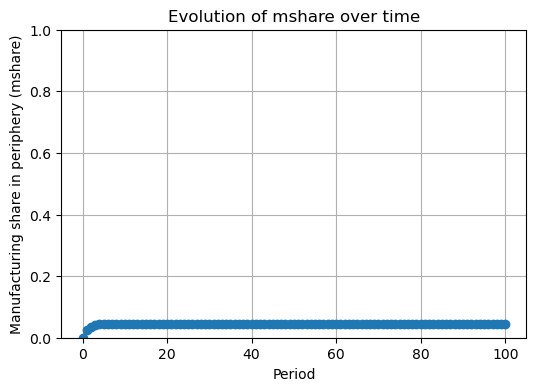

In [13]:
# and now we loop through updating the firm distribution for 100 periods
# and then plot what happens to the share of manufacturing in the periphery
# over those 100 periods


# Initial distribution
fb = 0.0   # both
fp = 0.0   # periphery-only

# Parameters
F = 0.4
tau = 1.0
alpha_p = 0.3
mu = 0.4

mshare = fp + fb / 2
dp = alpha_p + mu * mshare

# Behavioral parameters
lamb = 0.05   # fraction of one-plant firms opening a second plant
sigma = 0.5  # fraction of loss-making two-plant firms that close

mshare_path = [mshare]
periods = [0]

# Header
print("period  core_profit  per_profit  fp      fb      fc")

# Iterate for, say, 101 periods
for t in range(1, 101):
    result = one_period_update(
        fb=fb,
        fp=fp,
        dp=dp,
        F=F,
        tau=tau,
        lamb=lamb,
        sigma=sigma,
    )

    core_profit = result["core_profit"]
    per_profit = result["per_profit"]
    fb = result["fb"]
    fp = result["fp"]
    fc = 1 - fp - fb
    mshare = fp + fb / 2
    mshare_path.append(mshare)
    periods.append(t)

    print(
        f"{t:>3d}     "
        f"{core_profit!s:<11}  "
        f"{per_profit!s:<10}  "
        f"fp={fp:.4f}  "
        f"fb={fb:.4f}  "
        f"fc={fc:.4f}"
    )

    # update demand in periphery for next period
    mshare = fp + fb / 2
    dp = alpha_p + mu * mshare

# after the loop is over, plot mshare

plt.figure(figsize=(6, 4))
plt.plot(periods, mshare_path, marker="o")
plt.xlabel("Period")
plt.ylabel("Manufacturing share in periphery (mshare)")
plt.title("Evolution of mshare over time")
plt.ylim(0, 1)  # y-axis from 0 to 1
plt.grid(True)
plt.show()

# And We Are Done Building Our Scaffolding! Almost.

Now we want to box all of this up into a function, so we can apply it:

The function will be: simulate_evolving_firm_distribution(fb_init, fp_init, F, tau, alpha_p, mu, lamb, sigma, T), with:

* fb_init (default=0.0) being the initial share of firms with plants in both regions
* fp_init (default=0.0) being the initial share of firms with plants in only the periphery
* alpha_p (default=0.3) being the share of total demand that is agricultural demand in the periphery
* mu (default=0.4) being the share of total demand that comes from manufacturing-sector income 

* F (default=0.4) being the plant-operation cost
* tau (default=1) being the per-unit transport cost

* lamb (default=0.05) being the share of one-plant firms that try to open a plant in the other location each period
* sigma (default=0.5) being the share of loss-making plants that are closed each period

* T (default=100) being the number of periods that our simulation runs


In [14]:
# our function

import matplotlib.pyplot as plt

def simulate_evolving_firm_distribution(
    fb_init=0.0,
    fp_init=0.0,
    F=0.4,
    tau=1.0,
    alpha_p=0.3,
    mu=0.4,
    lamb=0.05,
    sigma=0.5,
    T=100
):
    """
    Run the Krugman-Lewis style dynamics starting from (fb_init, fp_init),
    print the first five lines of the firm-distribution evolution, and
    then plot the manufacturing share in the periphery over time.

    Parameters
    ----------
    fb_init : float
        Initial fraction of firms with plants in both regions.
    fp_init : float
        Initial fraction of firms with a single plant in the periphery.
    F, tau, alpha_p, mu : floats
        Technology/market-structure parameters as in the notebook.
    lamb : float
        Share of one-plant firms that open a second plant in a period.
    sigma : float
        Share of loss-making plants that close in a period.
    T : int
        Number of periods to simulate.
    """

    # Initial distribution
    fb = fb_init
    fp = fp_init

    # Initial demand in periphery
    mshare = fp + fb / 2
    dp = alpha_p + mu * mshare

    mshare_path = [mshare]
    periods = [0]

    # Header
    print("period  core_profit  per_profit  fp      fb      fc")

    # Iterate for T periods
    for t in range(1, T + 1):
        result = one_period_update(
            fb=fb,
            fp=fp,
            dp=dp,
            F=F,
            tau=tau,
            lamb=lamb,
            sigma=sigma,
        )

        core_profit = result["core_profit"]
        per_profit = result["per_profit"]
        fb = result["fb"]
        fp = result["fp"]
        fc = 1 - fp - fb

        mshare = fp + fb / 2
        mshare_path.append(mshare)
        periods.append(t)

        # Print only the first five lines
        if t <= 5:
            print(
                f"{t:>3d}"
                f"{core_profit!s:<11}"
                f"{per_profit!s:<10}"
                f"fp={fp:.4f}"
                f"  fb={fb:.4f}"
                f"  fc={fc:.4f}"
            )

        # update demand in periphery for next period
        dp = alpha_p + mu * mshare

    # Plot mshare after the loop is over
    plt.figure(figsize=(6, 4))
    plt.plot(periods, mshare_path, marker="o")
    plt.xlabel("Period")
    plt.ylabel("Manufacturing share in periphery (mshare)")
    plt.title("Evolution of mshare over time")
    plt.ylim(0, 1)  # y-axis from 0 to 1
    plt.grid(True)
    plt.show()


period  core_profit  per_profit  fp      fb      fc
  1True       False     fp=0.0000  fb=0.0500  fc=0.9500
  2True       False     fp=0.0000  fb=0.0725  fc=0.9275
  3True       False     fp=0.0000  fb=0.0826  fc=0.9174
  4True       False     fp=0.0000  fb=0.0872  fc=0.9128
  5True       False     fp=0.0000  fb=0.0892  fc=0.9108


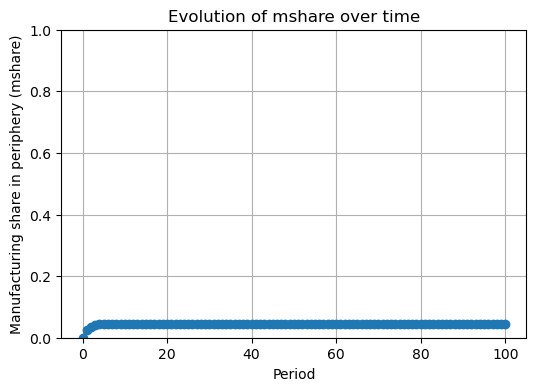

In [15]:
# and see if it runs

simulate_evolving_firm_distribution()

---
---

# Now Almost Time for the Main Event

The next step is to construct a loop to run a bunch of simulations for different parameter values. Here is an example, for the share of total production that is agricultural production in the periphery running from 0 to 0.6:


=== alpha_p = 0.1 ===
period  core_profit  per_profit  fp      fb      fc
  1True       False     fp=0.0000  fb=0.0500  fc=0.9500
  2True       False     fp=0.0000  fb=0.0725  fc=0.9275
  3True       False     fp=0.0000  fb=0.0826  fc=0.9174
  4True       False     fp=0.0000  fb=0.0872  fc=0.9128
  5True       False     fp=0.0000  fb=0.0892  fc=0.9108


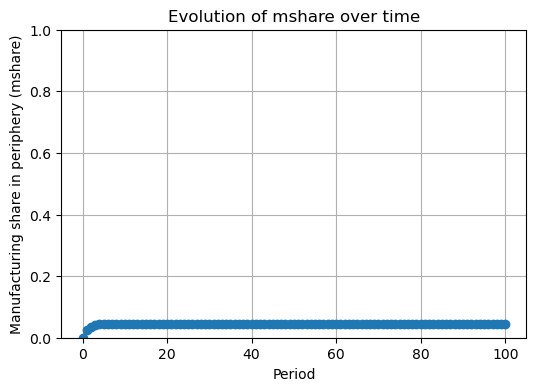


=== alpha_p = 0.3 ===
period  core_profit  per_profit  fp      fb      fc
  1True       False     fp=0.0000  fb=0.0500  fc=0.9500
  2True       False     fp=0.0000  fb=0.0725  fc=0.9275
  3True       False     fp=0.0000  fb=0.0826  fc=0.9174
  4True       False     fp=0.0000  fb=0.0872  fc=0.9128
  5True       False     fp=0.0000  fb=0.0892  fc=0.9108


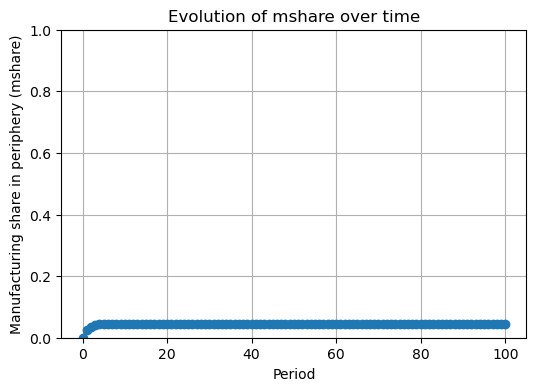


=== alpha_p = 0.5 ===
period  core_profit  per_profit  fp      fb      fc
  1True       True      fp=0.0000  fb=0.0500  fc=0.9500
  2True       True      fp=0.0000  fb=0.0975  fc=0.9025
  3True       True      fp=0.0000  fb=0.1426  fc=0.8574
  4True       True      fp=0.0000  fb=0.1855  fc=0.8145
  5True       True      fp=0.0000  fb=0.2262  fc=0.7738


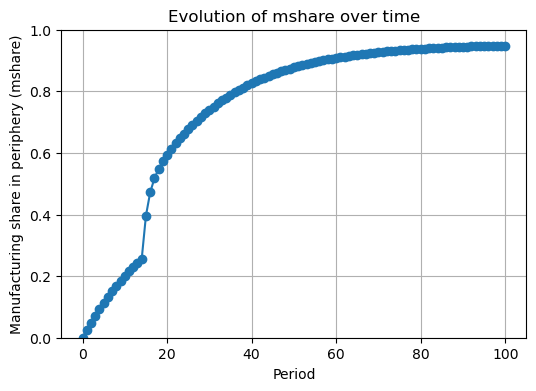

In [16]:
# loop over alpha_p from 0.1 to 0.5 in steps of 0.2

for alpha_p_val in [0.1, 0.3, 0.5]:
    print(f"\n=== alpha_p = {alpha_p_val:.1f} ===")
    simulate_evolving_firm_distribution(alpha_p=alpha_p_val)



=== alpha_p = 0.1 ===
period  core_profit  per_profit  fp      fb      fc
  1True       True      fp=0.9500  fb=0.0500  fc=0.0000
  2True       True      fp=0.9025  fb=0.0975  fc=0.0000
  3True       True      fp=0.8574  fb=0.1426  fc=0.0000
  4True       True      fp=0.8145  fb=0.1855  fc=0.0000
  5True       True      fp=0.7738  fb=0.2262  fc=0.0000


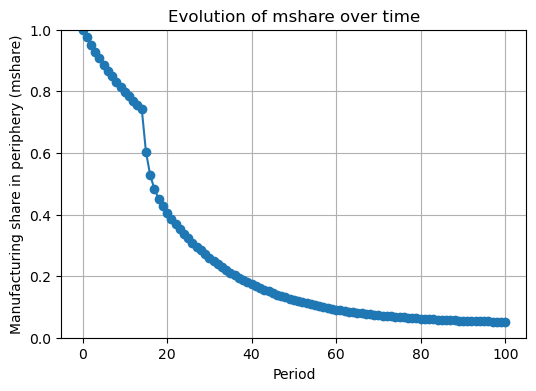


=== alpha_p = 0.3 ===
period  core_profit  per_profit  fp      fb      fc
  1False      True      fp=0.9500  fb=0.0500  fc=0.0000
  2False      True      fp=0.9275  fb=0.0725  fc=0.0000
  3False      True      fp=0.9174  fb=0.0826  fc=0.0000
  4False      True      fp=0.9128  fb=0.0872  fc=0.0000
  5False      True      fp=0.9108  fb=0.0892  fc=0.0000


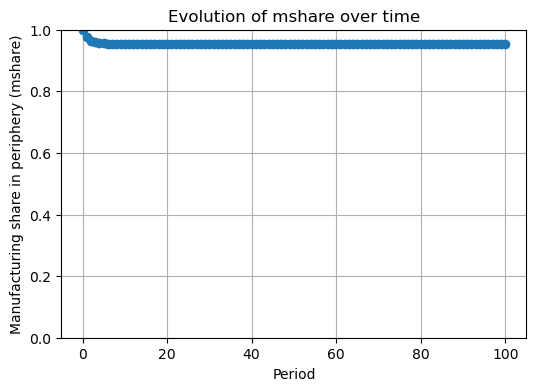


=== alpha_p = 0.5 ===
period  core_profit  per_profit  fp      fb      fc
  1False      True      fp=0.9500  fb=0.0500  fc=0.0000
  2False      True      fp=0.9275  fb=0.0725  fc=0.0000
  3False      True      fp=0.9174  fb=0.0826  fc=0.0000
  4False      True      fp=0.9128  fb=0.0872  fc=0.0000
  5False      True      fp=0.9108  fb=0.0892  fc=0.0000


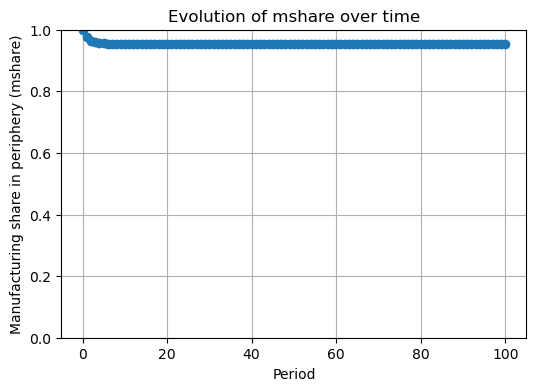

In [17]:
# suppose we had started with all rather than no manufacturing
# production in the periphery

for alpha_p_val in [0.1, 0.3, 0.5]:
    print(f"\n=== alpha_p = {alpha_p_val:.1f} ===")
    simulate_evolving_firm_distribution(fp_init=1.0, alpha_p=alpha_p_val)



=== alpha_p = 0.1 ===
period  core_profit  per_profit  fp      fb      fc
  1True       False     fp=0.0000  fb=0.5000  fc=0.5000
  2True       False     fp=0.0000  fb=0.2750  fc=0.7250
  3True       False     fp=0.0000  fb=0.1738  fc=0.8262
  4True       False     fp=0.0000  fb=0.1282  fc=0.8718
  5True       False     fp=0.0000  fb=0.1077  fc=0.8923


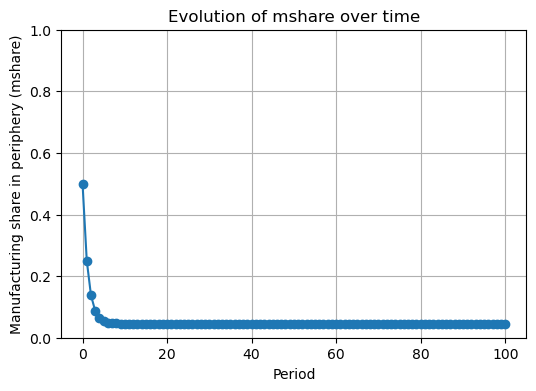


=== alpha_p = 0.3 ===
period  core_profit  per_profit  fp      fb      fc
  1True       True      fp=0.0000  fb=1.0000  fc=0.0000
  2True       True      fp=0.0000  fb=1.0000  fc=0.0000
  3True       True      fp=0.0000  fb=1.0000  fc=0.0000
  4True       True      fp=0.0000  fb=1.0000  fc=0.0000
  5True       True      fp=0.0000  fb=1.0000  fc=0.0000


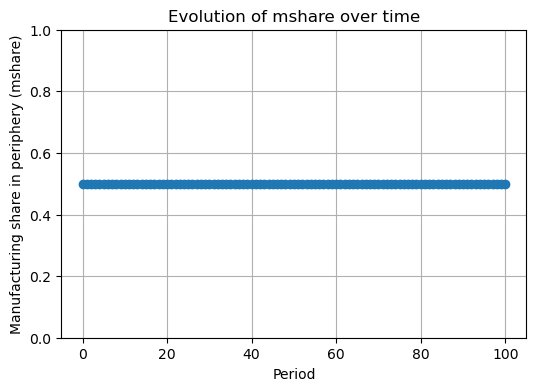


=== alpha_p = 0.5 ===
period  core_profit  per_profit  fp      fb      fc
  1False      True      fp=0.5000  fb=0.5000  fc=0.0000
  2False      True      fp=0.7250  fb=0.2750  fc=0.0000
  3False      True      fp=0.8262  fb=0.1738  fc=0.0000
  4False      True      fp=0.8718  fb=0.1282  fc=0.0000
  5False      True      fp=0.8923  fb=0.1077  fc=0.0000


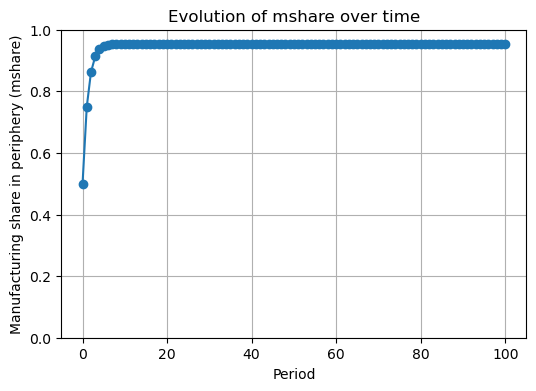

In [18]:
# and suppose we had started with manufacturing production split


for alpha_p_val in [0.1, 0.3, 0.5]:
    print(f"\n=== alpha_p = {alpha_p_val:.1f} ===")
    simulate_evolving_firm_distribution(fp_init=0, fb_init=1, alpha_p=alpha_p_val)


We have now nicely characterized how the model behaves with these parameter values as we look at different starting points and at different values for the share of demand that is agricultural production in the periphery. Maybe we want to make things cleaner? Here is an alternative function that just prints out the graph:

In [19]:
import matplotlib.pyplot as plt

def run_one_simulation(fp_init, fb_init, alpha_p,
                       F=0.4, tau=1.0, mu=0.4,
                       lamb=0.05, sigma=0.5, T=100):
    """
    Run the Krugman-Lewis dynamics once and return (periods, mshare_path).
    Relies on one_period_update() already being defined in the notebook.
    """
    fb = fb_init
    fp = fp_init

    # initial demand in periphery
    mshare = fp + fb / 2
    dp = alpha_p + mu * mshare

    mshare_path = [mshare]
    periods = [0]

    for t in range(1, T + 1):
        result = one_period_update(
            fb=fb,
            fp=fp,
            dp=dp,
            F=F,
            tau=tau,
            lamb=lamb,
            sigma=sigma,
        )

        fb = result["fb"]
        fp = result["fp"]
        mshare = fp + fb / 2

        mshare_path.append(mshare)
        periods.append(t)

        # update dp for next period
        dp = alpha_p + mu * mshare

    return periods, mshare_path

and here below is a code cell that prints out a nice-looking table of graphs for nine possibilities:


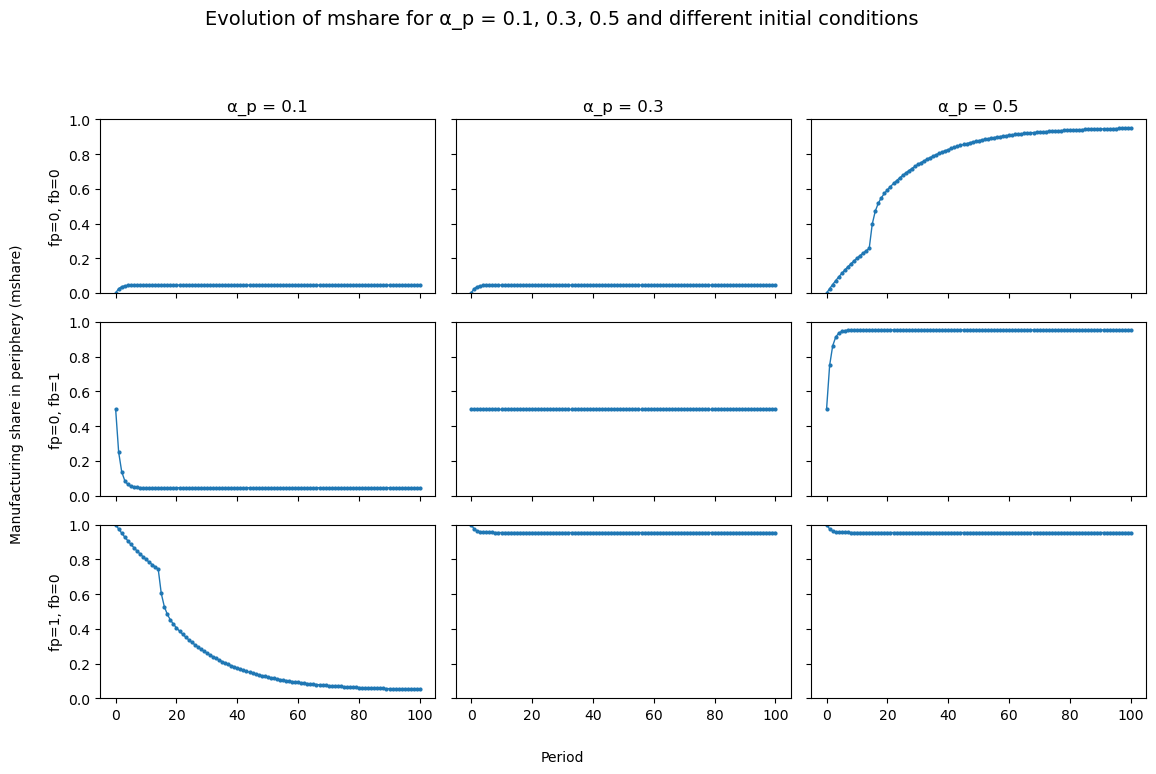

In [20]:
# α_p values for the columns
alpha_vals = [0.1, 0.3, 0.5]

# three initial conditions (rows):
# row 0: fp = 0, fb = 0
# row 1: fb = 1, fp = 0
# row 2: fp = 1, fb = 0
initial_conditions = [
    (0.0, 0.0),  # all in core
    (0.0, 1.0),  # split (both)
    (1.0, 0.0),  # all in periphery
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(12, 8),
    sharex=True,
    sharey=True
)

for col, alpha_p in enumerate(alpha_vals):
    for row, (fp_init, fb_init) in enumerate(initial_conditions):
        ax = axes[row, col]

        periods, mshare_path = run_one_simulation(
            fp_init=fp_init,
            fb_init=fb_init,
            alpha_p=alpha_p,
        )

        ax.plot(periods, mshare_path, marker="o", markersize=2, linewidth=1)

        if row == 0:
            ax.set_title(f"α_p = {alpha_p:.1f}")
        if col == 0:
            if row == 0:
                ic_label = "fp=0, fb=0"
            elif row == 1:
                ic_label = "fp=0, fb=1"
            else:
                ic_label = "fp=1, fb=0"
            ax.set_ylabel(ic_label)

        ax.set_ylim(0, 1)

# common x/y labels
fig.text(0.5, 0.04, "Period", ha="center")
fig.text(0.04, 0.5, "Manufacturing share in periphery (mshare)",
         va="center", rotation="vertical")
fig.suptitle("Evolution of mshare for α_p = 0.1, 0.3, 0.5 and different initial conditions",
             fontsize=14)

plt.tight_layout(rect=[0.06, 0.07, 1, 0.93])
plt.show()

---
---

# The Main Event

<span style="color: red;">Start doing your own work here!</span>

(1) The space of parameter values for this little model of Paul Krugman's has four dimensions:

1. How prosperous the periphery is—the share of total demand that is agricultural demand in the periphery.
2. How important the tradable goods sectors are-the share of total demand that is manufacturing demand which can be produced in different places and shipped all over the world.
3. How much more costly it is to produce in a decentralized rather than a centralized manner—the plant cost F.
4. how costly it is to carry goods around the globe—the transport cost $ \tau $ tau.

Your task now is to construct and carry out simulations varying those four parameter values until you are reasonably confident that you understand how the number and types of equilibrium positions that the model can settle in depend on those four parameters. Once you've reached your conclusions, tell them to me by writing below after the blue answer prompt. Then attach by pasting after this "ANSWER" text markdown cell any code cells you ran that seemed to you to be particularly informative in pushing you to arrive at your conclusions. Then move on:

<span style="color: blue;"><b>ANSWER</b></style>: 

---
---

(2) There are other parameter values in the model. There are the parameters lamb and sigma. There are the initial conditions fb_init and fp_init (and the implicit fc_init and mshare_init). These are in addition to the fundamental structural parameters: (1) the baseline prosperity of the periphery — that is, the income and demand that originates in the non-industrial, non-mobile sector; (2) the share of total income and demand that is potentially footloose and can migrate across regions; (3) the fixed costs of production, which determine the extent of economies of scale; and (4) transport costs.

The second set consists of initial conditions — specifically, the initial geographic distribution of economic activity across regions.

The third set consists of the behavioral parameters governing adjustment dynamics: the rules determining the rates at which plants open in growing regions and close in shrinking ones, which control the speed at which the economy moves toward equilibrium.

(a) For each parameter in the first set, explain intuitively how an increase in that parameter shifts the model's long-run equilibrium. Under what combinations of these parameters does the model predict agglomeration — the concentration of manufacturing in a single "core" region? Under what combinations does it predict dispersal?

<span style="color: blue;"><b>ANSWER</b></style>: 

(b) Given a fixed set of structural parameters from the first set, how do different initial conditions affect where the economy ultimately settles? Is the long-run equilibrium unique, or can multiple equilibria coexist? If multiple equilibria are possible, what determines which one the economy reaches?

<span style="color: blue;"><b>ANSWER</b></style>: 

(c) How do the adjustment-speed parameters in the third set affect the economy's path over time, even holding the eventual equilibrium fixed? In particular, can slow adjustment cause the economy to spend a long time in a configuration that is not its long-run resting point? Does the speed of adjustment ever affect which long-run equilibrium is reached?

<span style="color: blue;"><b>ANSWER</b></style>: 

(d) Consider a policy intervention — say, a reduction in transport costs — that shifts the structural parameters. How does the impact of that intervention depend on (i) where the economy currently sits relative to the new equilibrium, (ii) the initial conditions from which it started, and (iii) the speed of adjustment?

<span style="color: blue;"><b>ANSWER</b></style>: 

---
---

(3) The simple Krugman geography-and-trade model rests on a set of specific microeconomic assumptions that are easy to overlook because they are embedded in the model's functional forms rather than stated as explicit premises.

One example invisible to you is that there is an underlying assumption that the demand elasticity of substitution between different manufactured-good varieties takes a fixed value. That implies that producers of differentiated goods operate under monopolistic competition, choosing to produce only up to the point where they achieve a constant markup of price over marginal cost. This markup determines both the size of the market each firm optimally serves and the share of revenue that accrues to the firm as quasi-rent rather than passing to workers or consumers. Varying it would change the degree of market power, the equilibrium number and scale of firms, and the division of income between factors and monopoly rents—yet the model treats σ as a fixed parameter whose value is taken as given.

(a) Identify some other microeconomic features—concerning technology, preferences, or costs—that are implicitly fixed by the model's functional form assumptions and that could in principle be varied. For each you identify, state: (i) what the Krugman model assumes; (ii) what the realistic alternative or range of alternatives are; and (iii) how relaxing the assumption would change the model's qualitative behavior.

<span style="color: blue;"><b>ANSWER</b></style>: 

(b) Arthur Lewis's account of the origins of massive global inequality centers on the existence of a traditional sector with unlimited supplies of labor at near-subsistence wages, the migration of that labor into a modern industrial sector, and the capture of the resulting surplus by industrial capital — a process that sustains low wages and high profits until the surplus labor pool is exhausted.

For each microeconomic feature you identified in part (a), assess whether varying it would make the Lewis story more plausible, less plausible, or simply more complex within a Krugman-style general equilibrium framework. Pay particular attention to: (i) what determines whether a "core" industrial region emerges and sustains itself; (ii) what determines the wage in the industrial sector relative to the agricultural sector; and (iii) what happens to the markup and to the distribution of income as the economy develops.

<span style="color: blue;"><b>ANSWER</b></style>: 

(c) The Krugman model predicts agglomeration—the concentration of manufacturing in a core—as an equilibrium outcome driven by market-access and demand-linkage mechanisms. The Lewis model predicts persistent low wages in the developing periphery as an equilibrium outcome driven by surplus labor. Are these two mechanisms complements, substitutes, or independent? Could a unified model generate both simultaneously? What additional microeconomic ingredients would such a model need that neither Krugman nor Lewis individually supplies?

<span style="color: blue;"><b>ANSWER</b></style>: 

---
---

And:

(4) Krugman's 1991 *Geography & Trade* book is at: <<https://bcourses.berkeley.edu/files/94372051/download?download_frd=1>>. Skim through it. Back in 1991 Krugman did not really have the computer power at his disposal to easily and quickly do the simulations that I and you have done above, and his students really did not have the computer power. So a large chunk of Krugman's writing is a march through algebra, illustrated by analytic-geometric diagrams, in which equations become lines and curves and in which model equilibrium positions become points where curves cross.

From your and only your standpoint, which approach—the data-science simulations in this exercise assignment or the algebra and analytic geometry equations and diagrams—is a better road to your understanding Krugman's argument about the forces making for global manufacturing concentration and thus for a grossly unequal world? If you are going to weasel out of the question by saying "there has to be a balance", on which side, from your perspective, should the balance be weighted? And, to the extent you understand your own mental thought processes, why?

<span style="color: blue;"><b>ANSWER</b></style>: 

---
---

You are done! Print your completed (or uncompleted) notebook to pdf, and upload it at: <<https://bcourses.berkeley.edu/courses/1551896/assignments/9071605>>.